**Summary:** In this lesson, we'll fine tune a Stable Diffusion model using Low-Rank Adaptation (LoRA). We'll load a training data set of images and descriptions from Hugging Face. This data will be used to train a set of LoRA weights to fine-tune the image generation. After testing the fine-tuned model, the weights will uploaded to Hugging Face, so that other projects can use our fine-tuned model.

**Objectives:**

Download and explore a data set from Hugging Face.

Run LoRA to fine-tune a Stable Diffusion model.

Generate images with the fine-tuned model.

Upload the LoRA weights to Hugging Face.

**New Terms:**

Low-Rank Adaptation (LoRA)

Access token

In [1]:
import os
import sys
import datasets
import diffusers
import huggingface_hub
import requests
import torch
from dotenv import load_dotenv
from huggingface_hub import HfApi
from IPython.display import display

In [2]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("datasets version: ", datasets.__version__)
print("diffusers version: ", diffusers.__version__)
print("huggingface_hub version: ", huggingface_hub.__version__)
print("torch version:", torch.__version__)

Platform: linux
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
---
datasets version:  4.0.0
diffusers version:  0.36.0
huggingface_hub version:  0.36.0
torch version: 2.9.0+cu126


In [3]:
if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
else:
    device = "cpu"
    dtype = torch.float32

print(f"Using {device} device with {dtype} data type.")

Using cuda device with torch.float16 data type.


Load Stable Diffusion

We'll start by loading in the same Stable Diffusion pipeline we used in the previous lesson. We could use the StableDiffusionPipeline as before, if we wanted. But the diffusers library has a handy AutoPipelineForText2Image class, which will figure out the right pipeline to use based on the model it's given.

**Task 6.3.1: Load the Stable Diffusion v1.4 pipeline.**

In [4]:
MODEL_NAME = "CompVis/stable-diffusion-v1-4"

pipeline = diffusers.AutoPipelineForText2Image.from_pretrained(MODEL_NAME , torch_dtype=dtype)
pipeline.to(device)

print(type(pipeline))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


<class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'>


Does Stable Diffusion already know what she looks like?

**Task 6.3.2: Generate four images with the prompt, "My dog Maya."**

  0%|          | 0/50 [00:00<?, ?it/s]

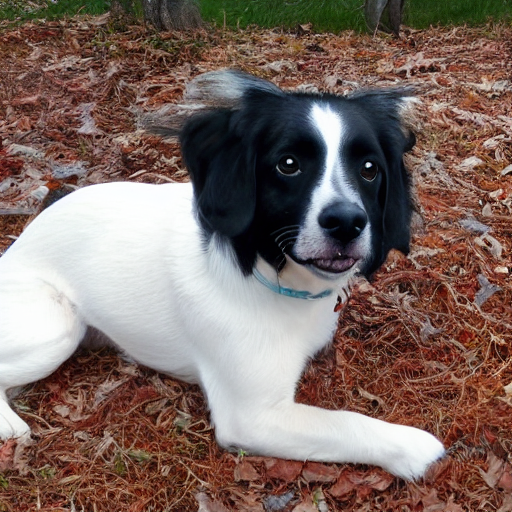

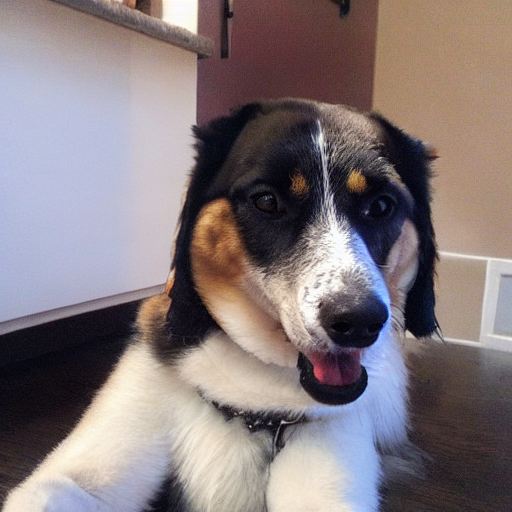

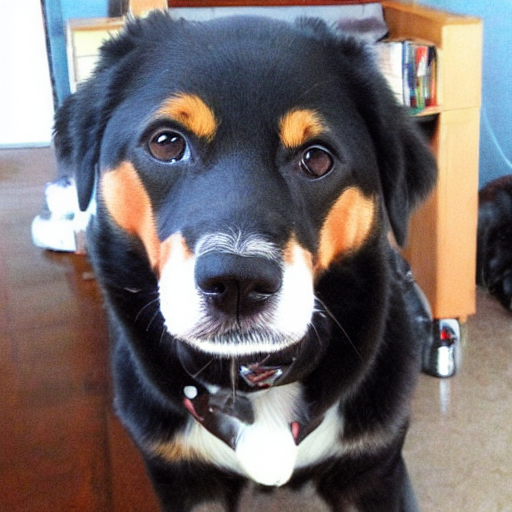

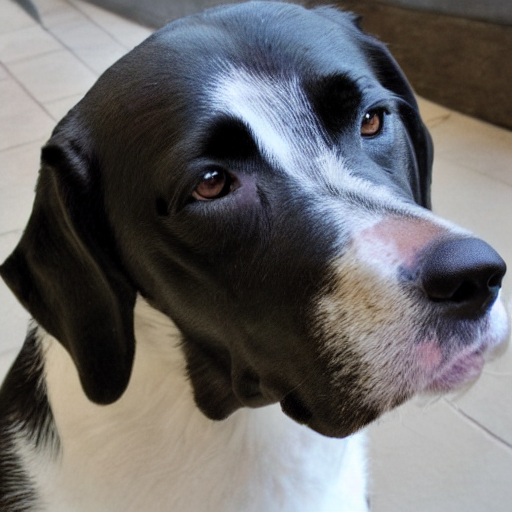

In [6]:
images = pipeline(["My dog Maya"] * 4).images

for im in images:
    display(im)

Load Data Set for Fine Tuning

While Stable Diffusion can produce many cute looking dogs, it obviously doesn't know what Maya looks like. And that's expected—clearly the model can't know what every dog in the entire world looks like!

We can fix that by fine-tuning the model on pictures of Maya. To do this, we'll need a data set with pictures of Maya. Luckily for us, this data set already exists on Hugging Face Hub!

Data sets on Hugging Face Hub are identified as user/dataset.

**Task 6.3.3: Create a data set builder, which will let us access metadata about this data set.**

In [7]:
DATASET_NAME ="worldquant-university/maya-dataset-v1"
data_builder = datasets.load_dataset_builder(DATASET_NAME)

print(data_builder.dataset_name)

README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

maya-dataset-v1


This builder object has downloaded metadata about the data set. This allows us to see what features are available, for example.

In [8]:
print(data_builder.info.features)

{'image': Image(mode=None, decode=True), 'text': Value('string')}


**Task 6.3.4: Determine which splits are included. There is a .splits attribute in the .info property of our builder.**

In [9]:
print(data_builder.info.splits)

{'train': SplitInfo(name='train', num_bytes=44012473, num_examples=26, shard_lengths=None, dataset_name='maya-dataset-v1')}


This builder didn't download all of the data. This is nice in general, since many data sets can be very large. We can see above that there are only 26 rows in this dataset, so we can afford to download the whole thing.

**Task 6.3.5: Load the Maya data set from Hugging Face Hub.**

In [17]:
from huggingface_hub import snapshot_download

# Download the dataset files locally
local_dataset_path = snapshot_download(repo_id=DATASET_NAME)

# Load the dataset using the 'imagefolder' builder and the local path
# The 'imagefolder' builder expects data_dir to point to a directory
# containing the image files (potentially in subfolders for different classes).
data = datasets.load_dataset("imagefolder", data_dir=local_dataset_path, ignore_verifications=True)

print(data)

RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-697db3bf-2839baf974d995d05cc99731;e1416d33-a6ec-4805-a724-2297618a3ab0)

Repository Not Found for url: https://huggingface.co/api/models/worldquant-university/maya-dataset-v1/revision/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

In [15]:
data["train"]["image"]

NameError: name 'data' is not defined

Task 6.3.6: Display the fourth image. (Or take a look at more of them, if you like!)

In [ ]:
# The values are PIL images, so they will be displayed
# automatically by Jupyter.
data["train"]["image"][3]

**Task 6.3.7: Print out the text associated with each row in the training data.**

In [ ]:
# Use dictionary indexing to look up the text values.
data["train"]["text"]

LoRA Fine-tuning

We have the model and we have the data, so we're ready to do the LoRA fine-tuning. The actual process is rather involved. Luckily, we don't have to program it ourselves. The diffusers project includes a script that does LoRA fine-tuning of a Hugging Face model based on a Hugging Face data set. There's a copy of this script in the same directory as this notebook: train_text_to_image_lora.py.

In addition to the model and data set names, we'll need to tell the script where to save the LoRA weights. It's up to you, but we'd recommend maya_model_v1_lora.

**Task 6.3.8: Set the OUTPUT_DIR variable with the correct value.**

In [ ]:
OUTPUT_DIR = "maya-model-v1-lora"

**Task 6.3.9: Inspect the train_text_to_image_lora.py script.**

Due to GPU limitations you CAN NOT run this script.

It's an advanced (and long) script. But if you want, take a look at it to familiarize yourself with the process of fine tuning.

Changes with respect to the video

The instructor in the video is executing the script in the notebook. But due to high GPU usage, we can't replicate it in your interactive environment.

Please, do NOT try running the script as it'll fail and restart your lab environment

Instead, we have already ran the script for you with different training epochs and stored the results in the output directory.

This command could take an hour to complete. Once it's done, there should be a pytorch_lora_weights.safetensors file in the output directory.

In [ ]:
!ls -l $OUTPUT_DIR

Load LoRA Weights
Now that we have the LoRA weights, we can load them into the pipeline we already have. The pipeline has a .load_lora_weights() method that can take a directory path as an argument. The file name of the weights file is given separately in the weight_name argument.

**Task 6.3.10: Load the LoRA weights into our pipeline.**

In [ ]:
pipeline.load_lora_weights(
    OUTPUT_DIR,
    weight_name="pytorch_lora_weights.10_epochs.safetensors",
)

**Task 6.3.11: Generate four images of "My dog Maya" with the fine-tuned model.**

In [ ]:
images = pipeline([" My dog Maya"] * 4).images

for im in images:
    display(im)

Conclusion
You've now used the fine-tuned model to produce images of our dog Maya that look (a bit more) like her. If we had more training data and had trained for more epochs, perhaps the model would perform even better. By using the LoRA algorithm, we could do the fine-tuning with only a fraction of the parameters in the original model. (Note that the file containing the LoRA weights is about 3 MB in size. The full weights for the Stable Diffusion model are about 3 GB in size!)

In the process, we've learned:

How to download data sets from Hugging Face.

How to run LoRA from a script.

How to load the LoRA weights into a Stable Diffusion pipeline.

How to set up a Hugging Face token for API access.



How to upload weights to Hugging Face repository.

In the next lesson, we'll use our fine-tuned model as a component in a Streamlit web app.